In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pyloki.config import ParamLimits, PulsarSearchConfig
from pyloki.detection import thresholding
from pyloki.ffa import DynamicProgramming
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.prune import prune_dyp_tree
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


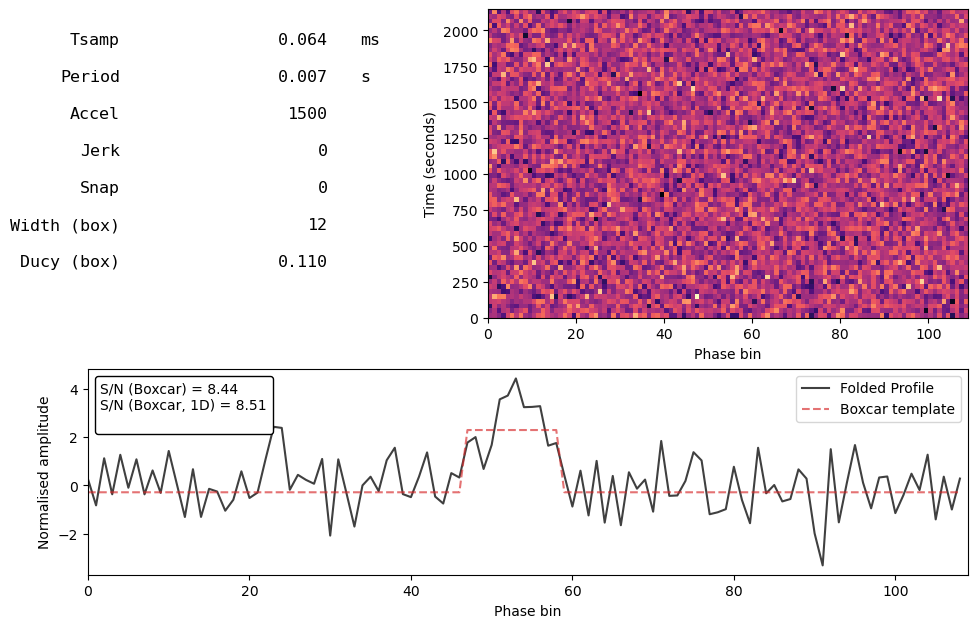

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 1500
nsamps = 2**25
mod_kwargs = {"acc": accel}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=8.5,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_taylor((140.0, 145.0), (-3000.0, 3000.0))
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 8192
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=2,
    ducy_max=0.2,
    wtsp=1.5,
    use_fourier=True,
    use_conservative_tile=False,
    branch_max=32,
)
dyp = DynamicProgramming(tim_data, search_cfg)
dyp.initialize()
dyp.execute()

Param limits: [[-3000.  3000.]
 [  140.   145.]]


2026-04-04 07:44:13 INFO     - pyloki.ffa - FFA initialize: Grid sizes: [7.52164558e+06 1.19209290e-01]

                    INFO     - pyloki.ffa - ffa level:  0, leaves: 5.36, fold dims: (8192, 1, 41, 2, 33)

                    INFO     - pyloki.ffa - ffa_initialize finished, Elapsed time: 0.520 seconds

Output()

...

                    INFO     - pyloki.ffa - ffa level:  3, leaves:  8.39, fold dims: (1024, 1, 335, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  5, leaves: 10.39, fold dims: (256, 1, 1342, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  6, leaves: 12.98, fold dims: (128, 3, 2684, 2, 33)

                    INFO     - pyloki.ffa - FFA complete: Grid sizes: [1.83633925e+03 1.86264515e-03]

                    INFO     - pyloki.ffa - ffa_execute finished, Elapsed time: 3.873 seconds

In [4]:
branching_pattern = search_cfg.generate_branching_pattern(kind="taylor", ref_seg=0)
branching_pattern

array([8.        , 6.        , 2.        , 2.        , 2.        ,
       1.        , 2.        , 2.        , 1.        , 2.        ,
       1.        , 1.        , 1.        , 2.        , 1.        ,
       2.        , 1.        , 1.        , 1.164307  , 1.71776   ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 2.        , 1.        , 1.        ,
       1.        , 2.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.66207154, 1.20331764,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.22876304,
       1.62765312, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 2.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

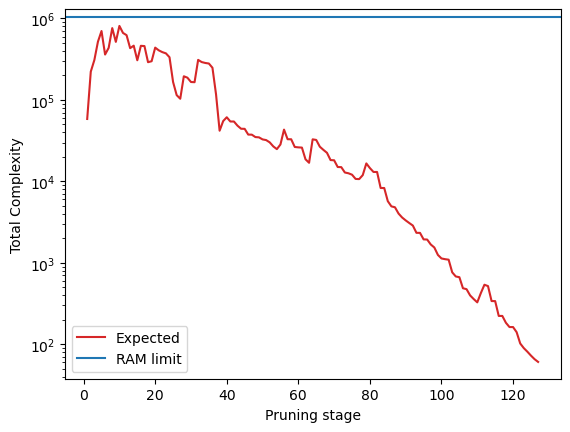

In [5]:
thresholds = np.array([2.1, 2.5, 2.6, 2.5, 2.7, 3. , 3.1, 2.9, 3.1, 3.1, 3.1, 2.9, 3.2,
       3.5, 3.6, 3.6, 3.2, 3.7, 3.6, 3.6, 3.5, 3.4, 3.3, 3.4, 3.9, 4. ,
       3.9, 3.8, 3.7, 3.8, 3.5, 3.6, 3.6, 3.5, 3.4, 3.6, 4.1, 4.5, 4.5,
       4.4, 4.4, 4. , 4.3, 4.3, 4. , 4.3, 4. , 4.2, 4. , 4.1, 4. , 4.1,
       4.2, 4.2, 4.2, 4.2, 4.4, 4. , 4.4, 4.2, 4.1, 4.5, 4.5, 4.4, 4.3,
       4.5, 4.5, 4.5, 4.6, 4.4, 4.6, 4.4, 4.6, 4.5, 4.5, 4.6, 4.4, 4.5,
       4.6, 4.7, 4.7, 4.4, 4.9, 4.5, 5. , 5. , 4.9, 5. , 5. , 5. , 5. ,
       5. , 5.1, 4.9, 5.1, 4.9, 5.1, 5.1, 5.2, 5.2, 5.1, 5. , 5.3, 5.3,
       5.2, 5.4, 5.3, 5.4, 5.4, 5.4, 5.4, 5.4, 5.4, 5.6, 5.3, 5.7, 5.3,
       5.7, 5.7, 5.3, 5.7, 5.8, 5.8, 5.8, 5.8, 5.8, 5.8])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=8.5,
    ducy_max=0.2,
    wtsp=1.5,
)
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**20, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [6]:
result_file = prune_dyp_tree(
    dyp,
    thresholds,
    n_runs=32,
    max_sugg=2**20,
    outdir="pruning_results/accel_test/",
    file_prefix="test_accel",
    poly_basis="taylor",
    n_workers=4,
    use_moving_grid=True,
)

2026-04-04 06:47:17 INFO     - pyloki.prune - Starting Pruning for 32 runs, with 4 workers

Output()

2026-04-04 06:47:21 INFO     - worker_000 - Initializing pruning run with ref segment: 0

                    INFO     - worker_004 - Initializing pruning run with ref segment: 4

2026-04-04 06:47:22 INFO     - worker_008 - Initializing pruning run with ref segment: 8

...

                    INFO     - worker_122 - Pruning time: Total: 6.2s (score: 51% | shift_add: 18% | branch: 13% | 
                             batch_add: 8%)

2026-04-04 06:48:51 INFO     - worker_127 - Pruning run complete for ref segment: 127

                    INFO     - worker_127 - Pruning stats: Score: 6.34, Leaves: 4.00

                    INFO     - worker_127 - Pruning time: Total: 6.7s (score: 50% | shift_add: 18% | branch: 14% | 
                             batch_add: 8%)

2026-04-04 06:48:53 INFO     - pyloki.prune - Pruning complete. Results saved to                                   
                             pruning_results/accel_test/test_accel_pruning_nstages_128_results.h5

In [7]:
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, run_id=None))

True params, a: 1500.000, f: 142.8571428571
Top candidates:
dparams: daccel: 0.2083917124, dfreq: 1.455191523e-05
Run: 110_28, S/N: 8.43, accel: 1499.88, freq: 142.857121
Run: 110_28, S/N: 8.39, accel: 1499.88, freq: 142.857135
Run: 110_28, S/N: 8.32, accel: 1499.88, freq: 142.857150
Run: 110_28, S/N: 8.25, accel: 1499.88, freq: 142.857164
Run: 110_28, S/N: 7.52, accel: 1500.09, freq: 142.857149
Run: 110_28, S/N: 7.49, accel: 1500.09, freq: 142.857134
Run: 110_28, S/N: 7.38, accel: 1500.30, freq: 142.857221
Run: 110_28, S/N: 7.28, accel: 1500.09, freq: 142.857178
Run: 000_01, S/N: 7.27, accel: -476.64, freq: 141.365432
Run: 110_28, S/N: 7.25, accel: 1500.30, freq: 142.857206


In [8]:
print(pgram.get_best_in_each_run())

Best candidate in each run:
dparams: daccel: 0.2083917124, dfreq: 1.455191523e-05
Run: 000_01, S/N: 7.27, accel: -476.64, freq: 141.365432
Run: 004_02, S/N: 6.40, accel: -584.63, freq: 141.053228
Run: 008_03, S/N: 6.70, accel: 317.39, freq: 143.984004
Run: 012_04, S/N: 6.82, accel: -1815.09, freq: 143.096536
Run: 016_05, S/N: 6.63, accel: 2350.17, freq: 140.443936
Run: 020_06, S/N: 6.54, accel: -1808.85, freq: 142.850040
Run: 024_07, S/N: 6.25, accel: -890.64, freq: 144.200684
Run: 028_08, S/N: 6.52, accel: -890.40, freq: 144.200677
Run: 032_09, S/N: 6.19, accel: -2073.97, freq: 142.634669
Run: 036_10, S/N: 6.08, accel: 181.94, freq: 142.186870
Run: 040_11, S/N: 6.31, accel: -685.49, freq: 141.822531
Run: 045_12, S/N: 6.53, accel: 1746.34, freq: 143.440746
Run: 049_13, S/N: 6.56, accel: 788.57, freq: 140.268116
Run: 053_14, S/N: 7.10, accel: -2352.87, freq: 141.954638
Run: 057_15, S/N: 6.72, accel: 1074.60, freq: 144.791003
Run: 061_16, S/N: 6.66, accel: -1632.41, freq: 140.511349
Run:

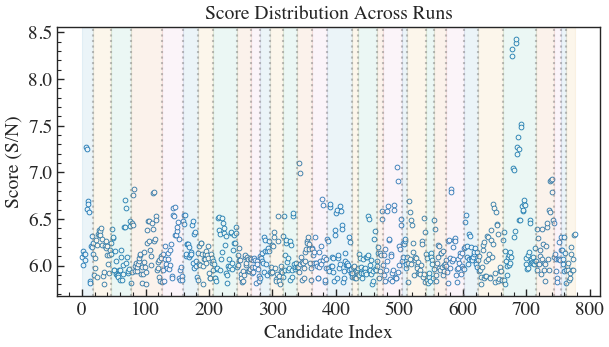

In [9]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()

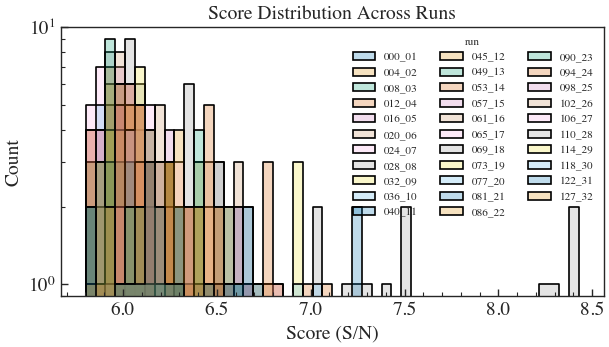

In [10]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

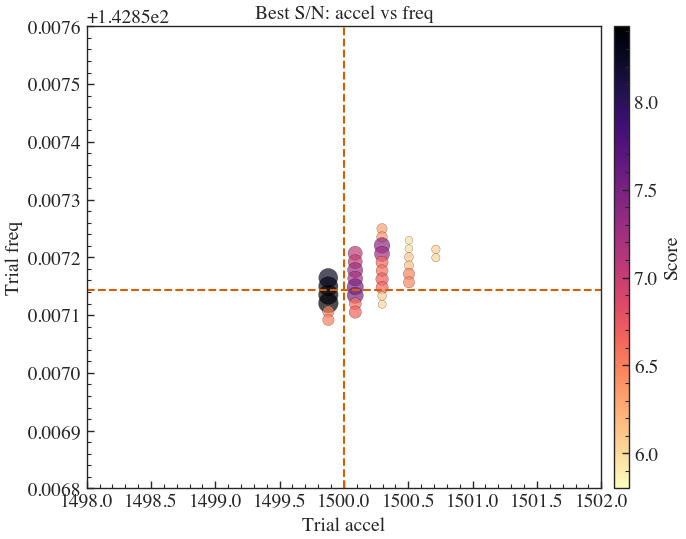

In [11]:
pgram.plot_correlation(
    "accel",
    "freq",
    true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq},
    x_lim=(1498, 1502),
    y_lim=(142.8568, 142.8576),
    run_id=None,
)
plt.show()

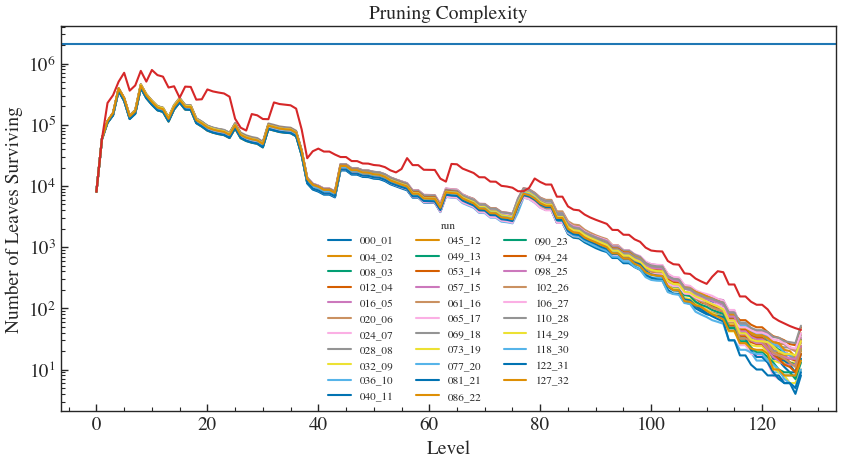

In [12]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(
    x,
    np.concatenate(([1], thresh_state.get_info("complexity"))) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
ax_list[0].axhline(2**21, label="RAM limit", c="tab:blue")
plt.show()

### Chebyshev basis

In [6]:
result_file = prune_dyp_tree(
    dyp,
    thresholds,
    n_runs=32,
    max_sugg=2**20,
    outdir="pruning_results/accel_cheby_test/",
    file_prefix="test_accel",
    poly_basis="chebyshev",
    n_workers=4,
    use_moving_grid=True,
)

                    INFO     - pyloki.prune - Starting Pruning for 32 runs, with 4 workers

Output()

2026-04-04 07:44:22 INFO     - worker_000 - Initializing pruning run with ref segment: 0

                    INFO     - worker_000 - prune_initialize finished, Elapsed time: 0.053 seconds

                    INFO     - worker_004 - Initializing pruning run with ref segment: 4

...

                    INFO     - worker_122 - Pruning time: Total: 6.9s (score: 48% | shift_add: 18% | branch: 13% | 
                             batch_add: 8%)

                    INFO     - worker_127 - Pruning run complete for ref segment: 127

                    INFO     - worker_127 - Pruning stats: Score: 6.13, Leaves: 4.46

                    INFO     - worker_127 - Pruning time: Total: 6.7s (score: 47% | shift_add: 19% | branch: 13% | 
                             batch_add: 8%)

2026-04-04 07:45:41 INFO     - pyloki.prune - Pruning complete. Results saved to                                   
                             pruning_results/accel_cheby_test/test_accel_pruning_nstages_128_results.h5

In [7]:
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, run_id=None))

True params, a: 1500.000, f: 142.8571428571
Top candidates:
dparams: daccel: 0.2094689265, dfreq: 1.455191523e-05
Run: 077_20, S/N: 7.90, accel: 1500.08, freq: 142.857191
Run: 077_20, S/N: 7.88, accel: 1500.08, freq: 142.857176
Run: 073_19, S/N: 7.86, accel: 1499.96, freq: 142.857166
Run: 073_19, S/N: 7.80, accel: 1499.96, freq: 142.857151
Run: 086_22, S/N: 7.77, accel: 1499.99, freq: 142.857162
Run: 086_22, S/N: 7.70, accel: 1499.99, freq: 142.857148
Run: 077_20, S/N: 7.70, accel: 1499.87, freq: 142.857169
Run: 086_22, S/N: 7.68, accel: 1500.20, freq: 142.857127
Run: 086_22, S/N: 7.68, accel: 1500.20, freq: 142.857142
Run: 077_20, S/N: 7.64, accel: 1499.87, freq: 142.857155


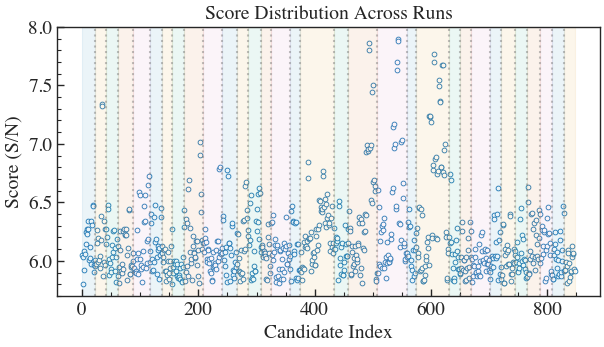

In [8]:
pgram.plot_scores(kind="scatter", run_id=None)
plt.show()